## Obtaining data

In [1]:
import os
import datetime

import psycopg2
import pandas as pd
import numpy as np

In [2]:
conn = psycopg2.connect(
    dbname=os.environ['POSTGRES_DB_NAME'], 
    user=os.environ['POSTGRES_USER'], 
    password=os.environ['POSTGRES_PASSWORD'], 
    host=os.environ['POSTGRES_HOST'], 
    port=os.environ['POSTGRES_PORT']
)

### Test dataset

In [3]:
clients_query = """
    SELECT *
    FROM marketing_campaign.clients cl
"""
test_df = pd.read_sql(clients_query, conn)
test_df['month'] = test_df['month'].apply(lambda d: datetime.datetime.strptime(d, '%b').month)
test_df

/tmp/ipykernel_14406/4290345109.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql(clients_query, conn)


,client_id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,1,58.0,management,married,tertiary,False,2143,True,False,unknown,5,5,261,1,False
1,2,44.0,technician,single,secondary,False,29,True,False,unknown,5,5,151,1,False
2,3,33.0,entrepreneur,married,secondary,False,2,True,True,unknown,5,5,76,1,False
3,4,47.0,blue-collar,married,unknown,False,1506,True,False,unknown,5,5,92,1,False
4,5,33.0,unknown,single,unknown,False,1,False,False,unknown,5,5,198,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,45207,51.0,technician,married,tertiary,False,825,False,False,cellular,17,11,977,3,True
45207,45208,71.0,retired,divorced,primary,False,1729,False,False,cellular,17,11,456,2,True
45208,45209,72.0,retired,married,secondary,False,5715,False,False,cellular,17,11,1127,5,True
45209,45210,57.0,blue-collar,married,secondary,False,668,False,False,telephone,17,11,508,4,False


### Ground truth dataset

In [4]:
contacts_count_query = """
    SELECT 
        cl.client_id, count(ca) as campaign
    FROM 
        marketing_campaign.clients cl
    LEFT JOIN 
        marketing_campaign.campaigns ca ON cl.client_id = ca.client_id
    GROUP BY 
        cl.client_id
"""
contacts_count = pd.read_sql(contacts_count_query, conn)

/tmp/ipykernel_14406/307892885.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contacts_count = pd.read_sql(contacts_count_query, conn)


In [5]:
last_outcome_query = """
    WITH LatestContact AS (
        SELECT
            ca.client_id,
            ca.contact_date,
            ca.contact_outcome,
            ROW_NUMBER() OVER (PARTITION BY ca.client_id ORDER BY ca.contact_date DESC) AS rn
        FROM
            marketing_campaign.campaigns ca
    )
    SELECT 
        cl.client_id, lc.contact_outcome
    FROM 
        marketing_campaign.clients cl
    LEFT JOIN 
        LatestContact lc ON cl.client_id = lc.client_id AND lc.rn = 1;
"""
last_outcome = pd.read_sql(last_outcome_query, conn)

/tmp/ipykernel_14406/1247663759.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  last_outcome = pd.read_sql(last_outcome_query, conn)


In [6]:
first_contact_query = """
    WITH FirstContact AS (
        SELECT
            ca.client_id,
            ca.contact_date,
            ca.contact_outcome,
            ROW_NUMBER() OVER (PARTITION BY ca.client_id ORDER BY ca.contact_date ASC) AS rn
        FROM
            marketing_campaign.campaigns ca
    )
    SELECT 
        cl.client_id, lc.contact_date as first_contact
    FROM 
        marketing_campaign.clients cl
    LEFT JOIN 
        FirstContact lc ON cl.client_id = lc.client_id AND lc.rn = 1;
"""
first_contact = pd.read_sql(first_contact_query, conn)

/tmp/ipykernel_14406/3605622783.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  first_contact = pd.read_sql(first_contact_query, conn)


In [7]:
ground_df = last_outcome.dropna().merge(
    test_df.drop(['campaign', 'day', 'month'], axis=1), 
    on='client_id', 
    how='left'
).merge(
    contacts_count,
    on='client_id', 
    how='left'
).merge(
    first_contact,
    on='client_id', 
    how='left'
)
ground_df['month'] = ground_df['first_contact'].apply(lambda d: d.month)
ground_df['day'] = ground_df['first_contact'].apply(lambda d: d.day)
ground_df.drop('first_contact', axis=1, inplace=True)
ground_df

,client_id,contact_outcome,age,job,marital,education,default,balance,housing,loan,contact,duration,y,campaign,month,day
0,24061,failure,33.0,admin.,married,tertiary,False,882,False,False,telephone,39,False,3,3,19
1,24063,other,42.0,admin.,single,secondary,False,-247,True,True,telephone,519,True,1,5,8
2,24065,failure,33.0,services,married,secondary,False,3444,True,False,telephone,144,True,4,5,1
3,24073,other,36.0,management,married,tertiary,False,2415,True,False,telephone,73,False,4,5,26
4,24078,failure,36.0,management,married,tertiary,False,0,True,False,telephone,140,True,3,3,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8252,45200,other,34.0,blue-collar,single,secondary,False,1475,True,False,cellular,1166,False,12,3,29
8253,45202,success,53.0,management,married,tertiary,False,583,False,False,cellular,226,True,4,3,4
8254,45205,failure,73.0,retired,married,secondary,False,2850,False,False,cellular,300,True,8,7,15
8255,45209,success,72.0,retired,married,secondary,False,5715,False,False,cellular,1127,True,3,2,16


## Data cleanup

In [8]:
import io

b1, b2 = io.StringIO(), io.StringIO()
test_df.info(buf=b1), ground_df.info(buf=b2)
b1, b2 = b1.getvalue(), b2.getvalue()

print('\n'.join(['{0:60}  {1}'.format(s1, s2) for s1, s2 in zip(b1.split('\n'), b2.split('\n'))]))

<class 'pandas.core.frame.DataFrame'>                         <class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210                         RangeIndex: 8257 entries, 0 to 8256
Data columns (total 15 columns):                              Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype                          #   Column           Non-Null Count  Dtype  
---  ------     --------------  -----                         ---  ------           --------------  -----  
 0   client_id  45211 non-null  int64                          0   client_id        8257 non-null   int64  
 1   age        45207 non-null  float64                        1   contact_outcome  8257 non-null   object 
 2   job        45211 non-null  object                         2   age              8257 non-null   float64
 3   marital    45211 non-null  object                         3   job              8257 non-null   object 
 4   education  45211 non-null  object                     

In [9]:
# We can fill empty age values with median from `test_df` since we posess the actual information about all the clients here
test_df.fillna(test_df['age'].median(), inplace=True)

In [10]:
# Better to drop 'NaN' strings from both datasets (there are few of them)
print(f"{ground_df['marital'].value_counts()['NaN']=}\n{test_df['marital'].value_counts()['NaN']=}")

ground_df['marital'].value_counts()['NaN']=1
test_df['marital'].value_counts()['NaN']=3


In [11]:
# On the one hand it is a problem since we wont get predictions for these customers
# On the other hand such entries are inapropriate, therefore we decide to drop them
test_df = test_df[test_df['marital'] != 'NaN']
ground_df = ground_df[ground_df['marital'] != 'NaN']

In [12]:
test_df.drop('client_id', axis=1, inplace=True)
ground_df.drop('client_id', axis=1, inplace=True)

/tmp/ipykernel_14406/3469149893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop('client_id', axis=1, inplace=True)
/tmp/ipykernel_14406/3469149893.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground_df.drop('client_id', axis=1, inplace=True)


In [13]:
# There's also few entries with unknown contact outcomes and we drop them because otherwise we would have strongly imbalanced dataset
ground_df['contact_outcome'].value_counts()

contact_outcome
failure    4900
other      1840
success    1511
unknown       5
Name: count, dtype: int64

In [14]:
ground_df = ground_df[ground_df['contact_outcome'] != 'unknown']

## Data exploration

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
CATEGORICAL_FEATURES = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'y'
]
NUMERICAL_FEATURES = [
    'age', 'balance', 'duration', 
    'campaign', 'month', 'day'
]
TARGET = 'contact_outcome'

In [17]:
ground_df[CATEGORICAL_FEATURES].T.apply(lambda row: list(row.unique()), axis=1).to_dict()

{'job': ['admin.',
  'services',
  'management',
  'technician',
  'blue-collar',
  'unemployed',
  'entrepreneur',
  'housemaid',
  'retired',
  'self-employed',
  'unknown',
  'student'],
 'marital': ['married', 'single', 'divorced'],
 'education': ['tertiary', 'secondary', 'primary', 'unknown'],
 'default': [False, True],
 'housing': [False, True],
 'loan': [False, True],
 'contact': ['telephone', 'unknown', 'cellular'],
 'y': [False, True]}

### Significance analysis

In [18]:
from typing import List, Literal
from scipy.stats import mannwhitneyu, chi2_contingency

def box_and_whisker(
    data: list, 
    title: str, 
    ylabel: str, 
    xticklabels: List[str],
    variable_type: Literal['continuous', 'categorical']
):
    ax = plt.axes()
    bp = ax.boxplot(data, widths=0.6, patch_artist=True)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(xticklabels)
    ax.tick_params(axis='x', which='major', length=0)
    xticks = [0.5] + [x + 0.5 for x in ax.get_xticks()]
    ax.set_xticks(xticks, minor=True)
    ax.tick_params(axis='x', which='minor', length=3, width=1)

    colors = sns.color_palette('pastel')
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    plt.setp(bp['medians'], color='k')

    significant_combinations = []
    ls = list(range(1, len(data) + 1))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for c in combinations:
        data1 = data[c[0] - 1]
        data2 = data[c[1] - 1]
        
        # Significance
        if variable_type == 'continuous':
            _, p = mannwhitneyu(data1, data2)
        elif variable_type == 'categorical':
            categories = set(data1 + data2)
            p = chi2_contingency(
                [
                    [data1.count(c) for c in categories], 
                    [data2.count(c) for c in categories]
                ]
            ).pvalue
        else:
            raise ValueError('`variable_type` argument can take only two values: "continuous" and "categorical"')
            
        if p < 0.05:
            significant_combinations.append([c, p])

    bottom, top = ax.get_ylim()
    yrange = top - bottom

    # Significance bars
    for i, significant_combination in enumerate(significant_combinations):
        x1 = significant_combination[0][0]
        x2 = significant_combination[0][1]

        level = len(significant_combinations) - i
        bar_height = (yrange * 0.08 * level) + top
        bar_tips = bar_height - (yrange * 0.02)
        plt.plot(
            [x1, x1, x2, x2],
            [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')

        
        p = significant_combination[1]
        if p < 0.001:
            sig_symbol = '***'
        elif p < 0.01:
            sig_symbol = '**'
        elif p < 0.05:
            sig_symbol = '*'
        text_height = bar_height + (yrange * 0.01)
        plt.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', c='k')

    bottom, top = ax.get_ylim()
    yrange = top - bottom
    ax.set_ylim(bottom - 0.02 * yrange, top)

    # Annotate sample size below each box
    for i, dataset in enumerate(data):
        sample_size = len(dataset)
        ax.text(i + 1, bottom, fr'n = {sample_size}', ha='center', size='x-small')

    plt.show()

In [19]:
def importance_plot(
    df: pd.DataFrame, 
    grouping_variable: str,
    tested_variable: str,
    variable_type: Literal['continuous', 'categorical']
):
    feature_groups = df.groupby(grouping_variable).apply(
        lambda group: group[tested_variable].to_list(), 
        include_groups=False
    ).to_dict()
    box_and_whisker(
        data=list(feature_groups.values()), 
        title=f'Significance test for `{tested_variable}`', 
        ylabel=tested_variable, 
        xticklabels=list(feature_groups.keys()),
        variable_type=variable_type
    )

In [20]:
# Simple categorical variables encoding
from copy import deepcopy
from sklearn.preprocessing import LabelEncoder

encoded_df = deepcopy(ground_df)
label_encoders = {}
for feature in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    encoded_df[feature] = le.fit_transform(encoded_df[feature])
    label_encoders[feature] = le

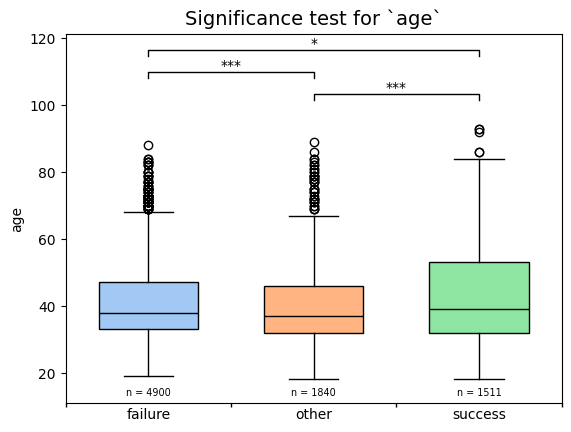

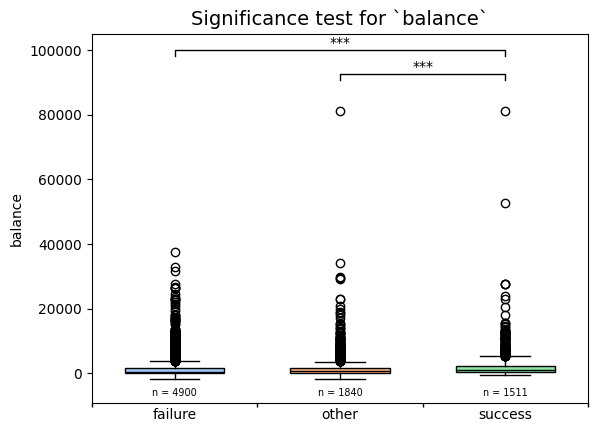

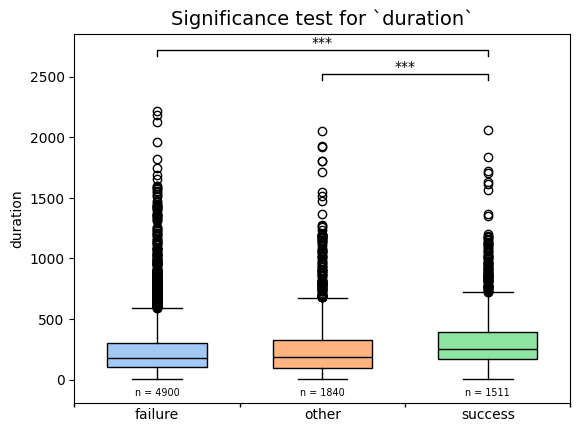

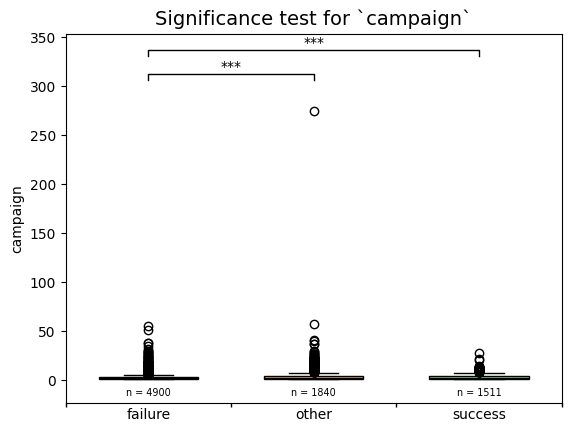

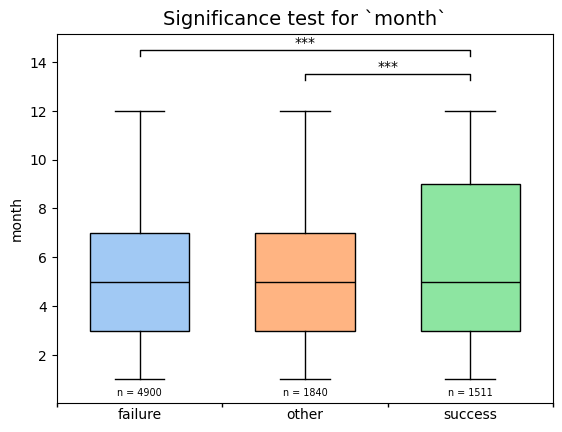

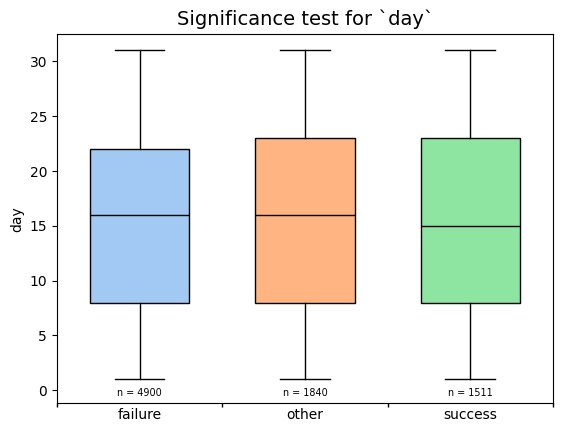

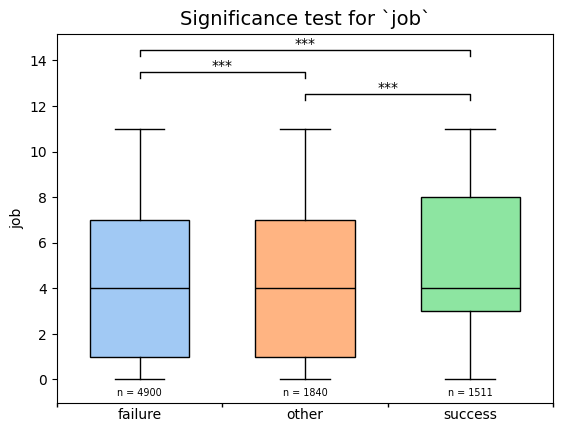

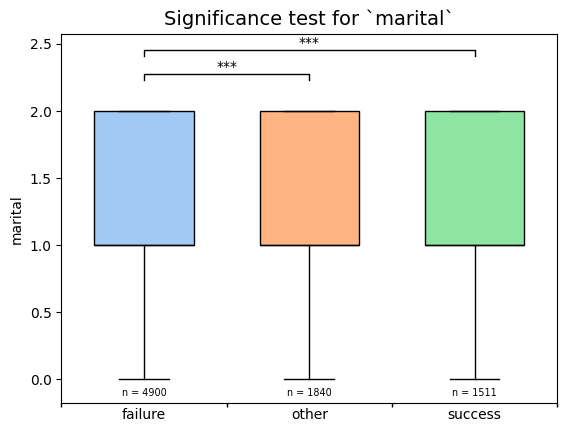

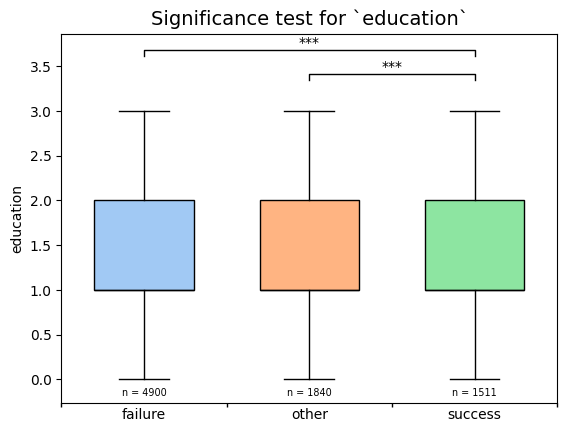

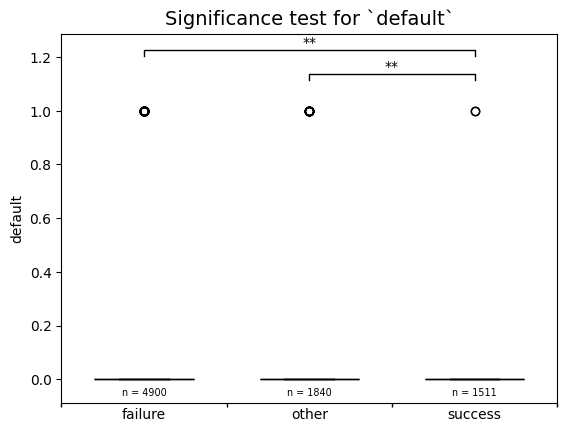

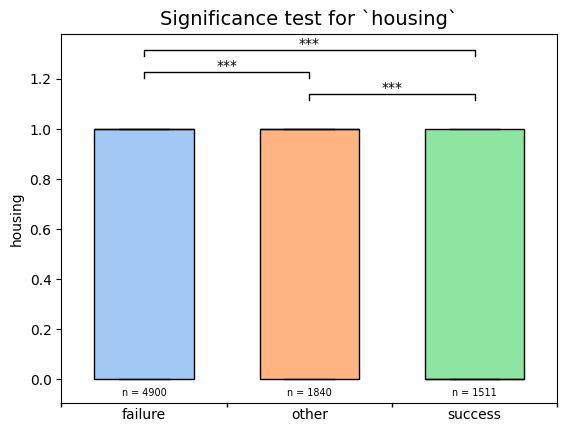

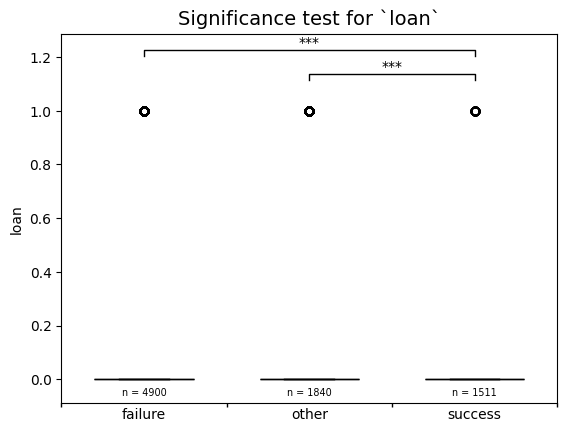

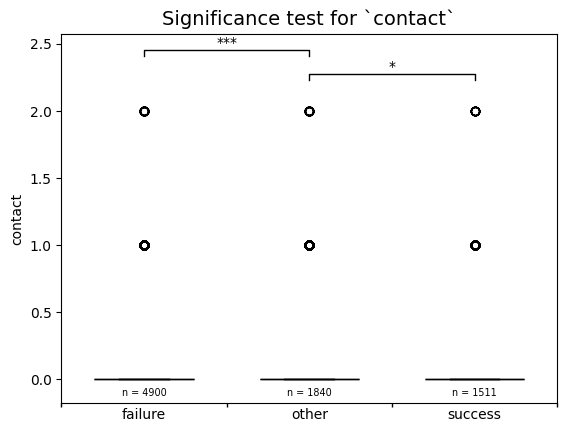

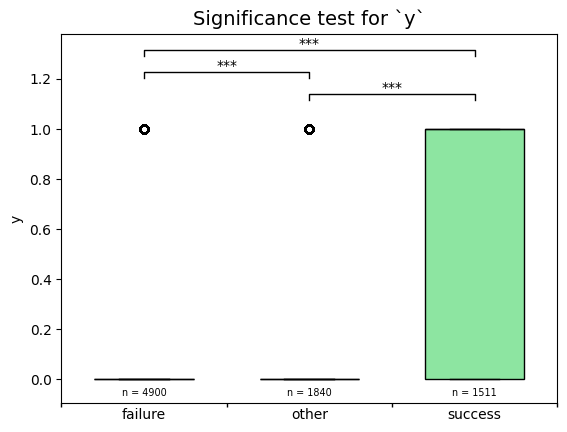

In [21]:
# Categorical features are tested using Chi-square test, whereas continuous using Mann-Whitney U test
for feature in NUMERICAL_FEATURES:
    importance_plot(
        df=encoded_df, 
        grouping_variable='contact_outcome',
        tested_variable=feature,
        variable_type='continuous'
    )
for feature in CATEGORICAL_FEATURES:
    importance_plot(
        df=encoded_df, 
        grouping_variable='contact_outcome',
        tested_variable=feature,
        variable_type='categorical'
    )

In [22]:
# We can drop `day` variable from our dataset since it's statistically insignificant
test_df.drop('day', axis=1, inplace=True)
ground_df.drop('day', axis=1, inplace=True)

/tmp/ipykernel_14406/1455311297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop('day', axis=1, inplace=True)


In [23]:
NUMERICAL_FEATURES.remove('day')

### Correllation analysis

In [24]:
# Simple categorical variables encoding
from copy import deepcopy
from sklearn.preprocessing import LabelEncoder

encoded_df = deepcopy(ground_df)
label_encoders = {}
for feature in CATEGORICAL_FEATURES + [TARGET]:
    le = LabelEncoder()
    encoded_df[feature] = le.fit_transform(encoded_df[feature])
    label_encoders[feature] = le

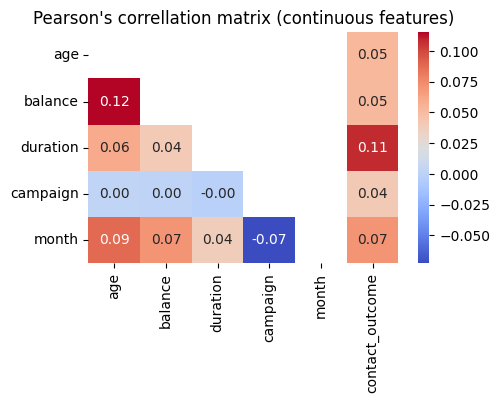

In [25]:
# Pearson's correllation for continuous variables
plt.figure(figsize=(5, 3))

corr = encoded_df[NUMERICAL_FEATURES + [TARGET]].corr().iloc[:-1]
mask = np.triu(np.ones_like(corr, dtype=bool))
mask[:, -1] = ~mask[:, -1]

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson's correllation matrix (continuous features)")
plt.show()

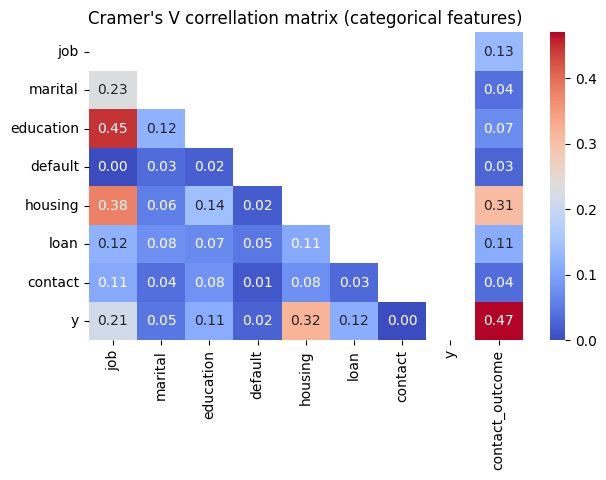

In [26]:
# Cramer's V correllation for continuous variables
def cramers_v(vector_1, vector_2):
    confusion_matrix = pd.crosstab(vector_1, vector_2)
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

plt.figure(figsize=(7, 4))

corr = encoded_df[CATEGORICAL_FEATURES + [TARGET]].corr(method=cramers_v).iloc[:-1]
mask = np.triu(np.ones_like(corr, dtype=bool))
mask[:, -1] = ~mask[:, -1]

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Cramer's V correllation matrix (categorical features)")
plt.show()

Now we see that contact outcome correllates the most with `y` and `housing` variables. Fewer correllation is observed with `job`, `loan` oraz `duration`. We will use these features to build the prediction model

In [27]:
# Note that there was weak correllation observed between `job` and `housing`, nevertheless we use both of them
SELECTED_FEATURES = ['y', 'housing', 'job', 'loan', 'duration']

## Modelling

In [28]:
import warnings

from tqdm.auto import tqdm, trange
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold

SELECTED_CATEGORICAL_FEATURES = list(set(CATEGORICAL_FEATURES) & set(SELECTED_FEATURES))
SELECTED_NUMERICAL_FEATURES = list(set(NUMERICAL_FEATURES) & set(SELECTED_FEATURES))

def train_and_evaluate_model(model) -> List[np.ndarray]:
    warnings.filterwarnings('ignore')

    precisions = []
    recalls = []
    f1_scores = []
    
    # We perform 5-folds cross validation 5 times randomly shuffling the dataset 
    # after each validation to ensure the results aren't just a matter of random
    kf = KFold(n_splits=5)
    for _ in trange(5, desc='Cross validation'):
        shuffled_df = ground_df.sample(frac=1)[SELECTED_FEATURES + [TARGET]]
        for train_index, test_index in tqdm(list(kf.split(shuffled_df)), desc='Splits evaluation', leave=False):
            y_train = shuffled_df.iloc[train_index][TARGET]
            y_test = shuffled_df.iloc[test_index][TARGET]
        
            # since we're interested in successfully ended contacts we can join 
            # `unknown` and `failure` outcomes making it a binary classification task
            y_train = y_train.apply(lambda outcome: 1 if outcome == 'success' else 0)
            y_test = y_test.apply(lambda outcome: 1 if outcome == 'success' else 0)
            
            # one-hot encoding for categorical variables
            one_hot_encoders = {}
            for feature in SELECTED_CATEGORICAL_FEATURES:
                encoder = OneHotEncoder()
                encoder.fit(shuffled_df.iloc[train_index][[feature]])
                one_hot_encoders[feature] = encoder
        
            X_train = shuffled_df.iloc[train_index][SELECTED_NUMERICAL_FEATURES].to_numpy()
            X_test = shuffled_df.iloc[test_index][SELECTED_NUMERICAL_FEATURES].to_numpy()
            for feature in SELECTED_CATEGORICAL_FEATURES:
                X_train = np.concatenate(
                    [X_train, one_hot_encoders[feature].transform(shuffled_df.iloc[train_index][[feature]]).toarray()], 
                    axis=1
                )
                X_test = np.concatenate(
                    [X_test, one_hot_encoders[feature].transform(shuffled_df.iloc[test_index][[feature]]).toarray()], 
                    axis=1
                )
        
            model.fit(
                X=X_train,
                y=y_train
            )
            y_pred = model.predict(X=X_test)
        
            precisions.append(precision_score(y_test, y_pred, average='weighted'))
            recalls.append(recall_score(y_test, y_pred, average='weighted'))
            f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
            
    warnings.resetwarnings()
    return np.array(precisions), np.array(recalls), np.array(f1_scores)

In [29]:
def print_result(
    precisions: np.ndarray, 
    recalls: np.ndarray, 
    f1_scores: np.ndarray, 
    name: str = ''
) -> None:
    result =(f'{name}\n' if name != '' else '') + (
        f'P:  {precisions.mean():.2f} ± {precisions.std():.2f}\n'
        f'R:  {recalls.mean():.2f} ± {recalls.std():.2f}\n'
        f'F1: {f1_scores.mean():.2f} ± {f1_scores.std():.2f}'
    )
    print(result)

According to the paper _[Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology._ for the task of contact outcome prediction best results achieves SVM model.

In [30]:
from sklearn.svm import LinearSVC
from sklearn.kernel_approximation import Nystroem

model = LinearSVC()
precisions, recalls, f1_scores = train_and_evaluate_model(model)
print_result(precisions, recalls, f1_scores, name='Eval results for SVM model')

Cross validation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Eval results for SVM model
P:  0.79 ± 0.06
R:  0.82 ± 0.01
F1: 0.79 ± 0.04


Not bad. The results are comparable to the mentioned paper, but let's also try something else

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=300, subsample=0.3)
precisions, recalls, f1_scores = train_and_evaluate_model(model)
print_result(precisions, recalls, f1_scores, name='Eval results for stochastic gradiend boosting model')

Cross validation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Eval results for stochastic gradiend boosting model
P:  0.82 ± 0.01
R:  0.83 ± 0.01
F1: 0.82 ± 0.01
